## 1

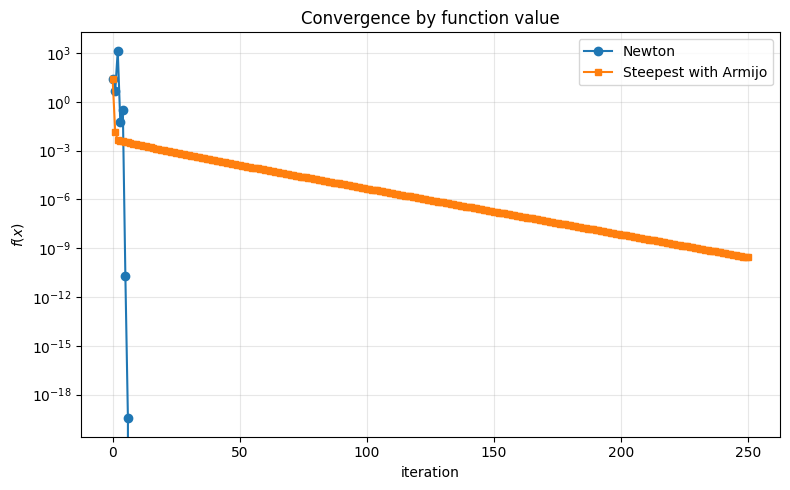

Newton: число шагов 7 финальное f 0.0
Newton финальная точка [1. 1.]
Steepest with Armijo: финальное f 2.7097756887567074e-10 точка [0.99998357 0.99996704]
Steepest with Armijo: число шагов 250


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(z):
    x, y = z[0], z[1]
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

def rosen_grad(z):
    x, y = z[0], z[1]
    gx = -2 * (1 - x) - 400 * x * (y - x ** 2)
    gy = 200 * (y - x ** 2)
    return np.array([gx, gy], dtype=float)

def rosen_hess(z):
    x, y = z[0], z[1]
    h11 = 2 - 400 * (y - x ** 2) + 800 * x ** 2
    h12 = -400 * x
    h22 = 200
    return np.array([[h11, h12], [h12, h22]], dtype=float)

def newton_rosenbrock(z0, max_iter=50, tol=1e-12):
    z = np.array(z0, dtype=float)
    path = [z.copy()]
    vals = [rosenbrock(z)]
    for _ in range(max_iter):
        g = rosen_grad(z)
        if np.linalg.norm(g) < tol:
            break
        H = rosen_hess(z)
        try:
            d = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            d = np.linalg.lstsq(H, -g, rcond=None)[0]
        z = z + d
        path.append(z.copy())
        vals.append(rosenbrock(z))
    return np.array(path), np.array(vals)

def steepest_rosenbrock_armijo(z0, alpha0=1.0, c=0.1, beta=0.5, max_iter=10000, tol=1e-8, record_every=40):
    z = np.array(z0, dtype=float)
    path = [z.copy()]
    vals = [rosenbrock(z)]

    for k in range(max_iter):
        g = rosen_grad(z)
        if np.linalg.norm(g) < tol:
            break

        d = -g
        alpha = alpha0
        f_current = rosenbrock(z)
        slope = np.dot(g, d)

        while rosenbrock(z + alpha * d) > f_current + c * alpha * slope:
            alpha *= beta

        z = z + alpha * d

        if (k + 1) % record_every == 0 or k == max_iter - 1:
            path.append(z.copy())
            vals.append(rosenbrock(z))

    return np.array(path), np.array(vals)

z0 = np.array([-1.2, 1.0])
path_n, vals_n = newton_rosenbrock(z0)
path_sd, vals_sd = steepest_rosenbrock_armijo(z0, alpha0=1.0, c=1e-4, beta=0.5)

plt.figure(figsize=(8, 5))
plt.semilogy(np.arange(len(vals_n)), vals_n, "o-", label="Newton", markersize=6)
plt.semilogy(np.arange(len(vals_sd)), vals_sd, "s-", label="Steepest with Armijo", markersize=4)
plt.xlabel("iteration")
plt.ylabel("$f(x)$")
plt.title("Convergence by function value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Newton: число шагов", len(vals_n) - 1, "финальное f", vals_n[-1])
print("Newton финальная точка", path_n[-1])
print("Steepest with Armijo: финальное f", vals_sd[-1], "точка", path_sd[-1])
print("Steepest with Armijo: число шагов", len(vals_sd) - 1)

### Вывод
Метод Ньютона требует для сходимости до 10 итераций и сходится почти точно в 0, а наискорейший спуск демонстрирует частные колебания и медленно снижается, но при этом даже за 300 шагов не приблизится близко к истинному значению

## 2

In [2]:
!pip install ucimlrepo

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import jax
from jax import numpy as jnp, grad
from scipy.optimize import minimize_scalar
import jax.numpy as jnp
from jax import grad, jit, hessian
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
from ucimlrepo import fetch_ucirepo
from optax.losses import safe_softmax_cross_entropy as cros_entr
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
import sklearn.datasets as skldata

# Set a random seed for reproducibility
np.random.seed(228)
jax.random.PRNGKey(228)

@jit
def logistic_loss(w, X, y, mu=1):
    m, n = X.shape
    logits = X @ w
    # BCE loss for y in {0,1}: -[y*log(sigma) + (1-y)*log(1-sigma)]
    # Numerically stable: -y*logits + log(1+exp(logits))
    bce = -y * logits + jnp.logaddexp(0, logits)
    return jnp.sum(bce) / m + mu / 2 * jnp.sum(w**2)

def generate_problem(m=1000, n=300, mu=1):
    X, y = skldata.make_classification(n_classes=2, n_features=n, n_samples=m, n_informative=n//2, random_state=0)
    X = jnp.array(X)
    y = jnp.array(y, dtype=jnp.float64)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

    return X_train, y_train, X_test, y_test

def compute_optimal(X, y, mu):
    w = cp.Variable(X.shape[1])
    logits = X @ w
    # BCE for y in {0,1}: -y*logits + log(1+exp(logits))
    bce = -cp.multiply(y, logits) + cp.logistic(logits)
    objective = cp.Minimize(cp.sum(bce) / len(y) + mu / 2 * cp.norm(w, 2)**2)
    problem = cp.Problem(objective)
    problem.solve()
    return w.value, problem.value

@jit
def compute_accuracy(w, X, y):
    # Compute predicted probabilities using the logistic (sigmoid) function
    preds_probs = jax.nn.sigmoid(X @ w)
    # Convert probabilities to class predictions: 0 if p < 0.5, else 1
    preds = jnp.where(preds_probs < 0.5, 0, 1)
    # Calculate accuracy as the average of correct predictions
    accuracy = jnp.mean(preds == y)
    return accuracy



# @jit
def compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, mu):
    f = lambda w: logistic_loss(w, X_train, y_train, mu)
    metrics = {
        "f_gap": [jnp.abs(f(x) - f_star) for x in trajectory],
        "x_gap": [jnp.linalg.norm(x - x_star) for x in trajectory],
        "time": times,
        "train_acc": [compute_accuracy(x, X_train, y_train) for x in trajectory],
        "test_acc": [compute_accuracy(x, X_test, y_test) for x in trajectory],
    }
    return metrics

def gradient_descent(w_0, X, y, learning_rate=0.01, num_iters=100, mu=0):
    trajectory = [w_0]
    times = [0]
    w = w_0
    f = lambda w: logistic_loss(w, X, y, mu)
    iter_start = time.time()
    for i in range(num_iters):
        grad_val = grad(f)(w)
        if learning_rate == "linesearch":
            # Simple line search implementation
            phi = lambda alpha: f(w - alpha*grad_val)
            result = minimize_scalar(fun=phi,
                                     bounds=(1e-3, 2e2)
                              )
            step_size = result.x
        else:
            step_size = learning_rate
        w -= step_size * grad_val
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)
    return trajectory, times

def newton_method(w_0, X, y, damping=2e-1, num_iters=100, mu=0):
    trajectory = [w_0]
    times = [0]
    w = w_0
    f = lambda w: logistic_loss(w, X, y, mu)

    iter_start = time.time()
    for i in range(num_iters):
        gradient = grad(f)(w)
        hessian_matrix = hessian(f)(w)

        # Reshape the Hessian matrix
        hessian_reshaped = hessian_matrix.reshape(w.size, w.size)

        # Calculate the Newton step using the reshaped Hessian
        newton_step = jnp.linalg.solve(hessian_reshaped, gradient.ravel()).reshape(w.shape)

        # Update parameters using a damping factor
        w -= damping * newton_step

        # Store trajectory and time
        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)

    return trajectory, times

def newton_method_cg(w_0, X, y, damping=1.0, num_iters=100, mu=0):
    trajectory = [w_0]
    times = [0]
    w = w_0
    f = lambda w: logistic_loss(w, X, y, mu)

    iter_start = time.time()
    for i in range(num_iters):
        gradient = grad(f)(w)
        hessian_matrix = hessian(f)(w)
        hessian_reshaped = hessian_matrix.reshape(w.size, w.size)

        # Решаем H * d = -g
        newton_step, _ = jax.scipy.sparse.linalg.cg(hessian_reshaped, -gradient, tol=1e-3, maxiter=w.size)

        w = w + newton_step

        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)

    return trajectory, times

def newton_method_hfn(w_0, X, y, damping=1.0, num_iters=100, mu=0):
    trajectory = [w_0]
    times = [0]
    w = w_0
    f = lambda w: logistic_loss(w, X, y, mu)

    # Функция для вычисления Hessian-vector произведения
    def hvp(v):
        return jax.jvp(grad(f), (w,), (v,))[1]

    iter_start = time.time()
    for i in range(num_iters):
        gradient = grad(f)(w)

        newton_step, _ = jax.scipy.sparse.linalg.cg(hvp, -gradient, tol=1e-5, maxiter=w.size)

        w = w + damping * newton_step

        iter_time = time.time()
        trajectory.append(w)
        times.append(iter_time - iter_start)

    return trajectory, times

def run_experiments(params):
    mu = params["mu"]
    m, n = params["m"], params["n"]
    methods = params["methods"]
    results = {}

    X_train, y_train, X_test, y_test = generate_problem(m, n, mu)
    n_features = X_train.shape[1]  # Number of features
    params["n_features"] = n_features

    x_0 = jax.random.normal(jax.random.PRNGKey(0), (n_features, ))
    x_star, f_star = compute_optimal(X_train, y_train, mu)

    for method in methods:
        if method["method"] == "GD":
            learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times = gradient_descent(x_0, X_train, y_train, learning_rate, iterations, mu)
            label = method["method"] + " " + str(learning_rate)
            results[label] = compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, mu)
        elif method["method"] == "Newton":
            if "learning_rate" not in method.keys():
                learning_rate = 1
            else:
                learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times = newton_method(x_0, X_train, y_train, learning_rate, iterations, mu)
            label = method["method"] + " " + str(learning_rate)
            results[label] = compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, mu)
        elif method["method"] == "Newton-CG":
            if "learning_rate" not in method.keys():
                learning_rate = 1
            else:
                learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times = newton_method_cg(x_0, X_train, y_train, learning_rate, iterations, mu)
            label = method["method"] + " " + str(learning_rate)
            results[label] = compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, mu)
        elif method["method"] == "Newton-HFN":
            if "learning_rate" not in method.keys():
                learning_rate = 1
            else:
                learning_rate = method["learning_rate"]
            iterations = method["iterations"]
            trajectory, times = newton_method_hfn(x_0, X_train, y_train, learning_rate, iterations, mu)
            label = method["method"] + " " + str(learning_rate)
            results[label] = compute_metrics(trajectory, x_star, f_star, times, X_train, y_train, X_test, y_test, mu)

    return results, params

def plot_results(results, params):
    plt.figure(figsize=(11, 5))
    mu = params["mu"]

    if mu > 1e-2:
        plt.suptitle(f"Strongly convex binary logistic regression. mu={mu}.")
    else:
        plt.suptitle(f"Convex binary logistic regression. mu={mu}.")

    plt.subplot(2, 4, 1)
    for method, metrics in results.items():
        plt.plot(metrics['f_gap'])
    plt.xlabel('Iteration')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 2)
    for method, metrics in results.items():
        plt.plot(metrics['x_gap'], label=method)
    plt.xlabel('Iteration')
    plt.ylabel('$\|x_k - x^*\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 3)
    for method, metrics in results.items():
        plt.plot(metrics["train_acc"])
    plt.xlabel('Iteration')
    plt.ylabel('Train accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 4)
    for method, metrics in results.items():
        plt.plot(metrics["test_acc"])
    plt.xlabel('Iteration')
    plt.ylabel('Test accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 5)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics['f_gap'])
    plt.xlabel('Time')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 6)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics['x_gap'])
    plt.xlabel('Time')
    plt.ylabel('$\|x_k - x^*\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 7)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics["train_acc"])
    plt.xlabel('Time')
    plt.ylabel('Train accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(2, 4, 8)
    for method, metrics in results.items():
        plt.plot(metrics["time"], metrics["test_acc"])
    plt.xlabel('Time')
    plt.ylabel('Test accuracy')
    # plt.yscale('log')
    plt.grid(linestyle=":")

    # Place the legend below the plots
    plt.figlegend(loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.00))
    # Adjust layout to make space for the legend below
    filename = ""
    for method, metrics in results.items():
        filename += method
    filename += f"_{mu}.pdf"
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(filename)
    plt.show()

<>:242: SyntaxWarning: invalid escape sequence '\|'
<>:274: SyntaxWarning: invalid escape sequence '\|'
<>:242: SyntaxWarning: invalid escape sequence '\|'
<>:274: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_4624/3869325509.py:242: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|x_k - x^*\|$')
/tmp/ipykernel_4624/3869325509.py:274: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|x_k - x^*\|$')


### 1) При значениях LR от 0.1-0.5 метод GD сходится линейно благодаря шагу и сильной выпуклости

/tmp/ipykernel_4624/884175311.py:34: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.array(y, dtype=jnp.float64)


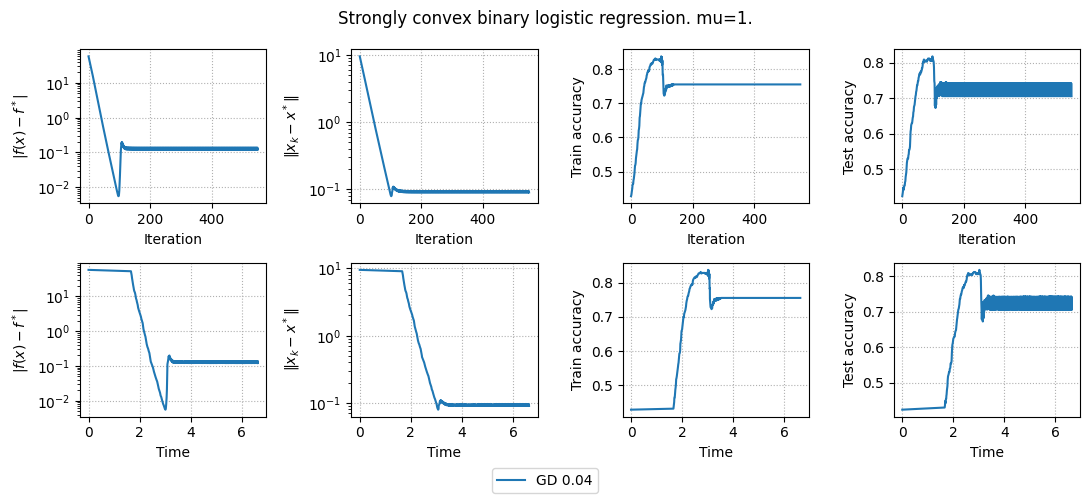

In [4]:
params_mu1 = {
    "mu": 1,
    "m": 1000,
    "n": 100,
    "methods": [
        {"method": "GD", "learning_rate": 0.04, "iterations": 550},
    ],
}

results, params = run_experiments(params_mu1)
plot_results(results, params_mu1)

### 2) Ньютон сходится нестабильно

/tmp/ipykernel_4624/884175311.py:34: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.array(y, dtype=jnp.float64)


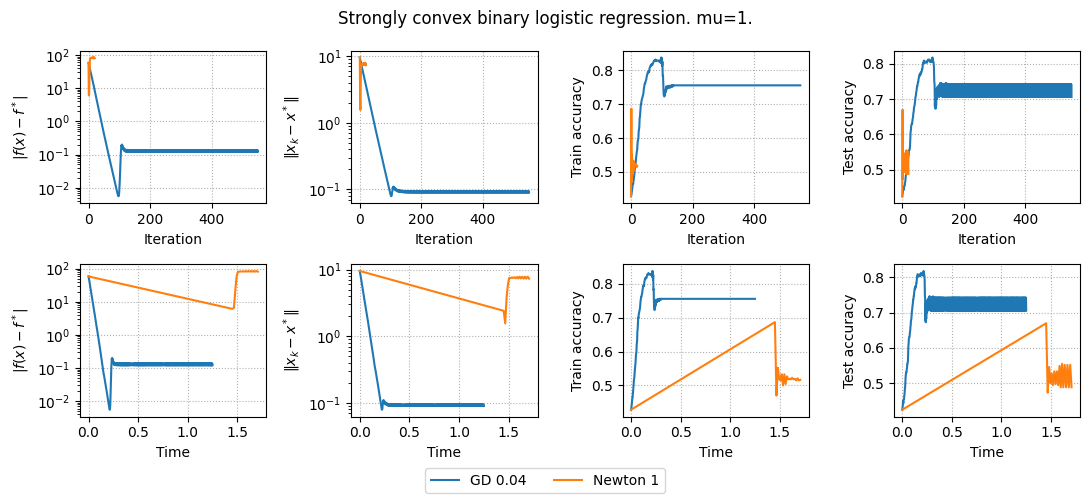

In [5]:
params = {
    "mu": 1,
    "m": 1000,
    "n": 100,
    "methods": [
        {"method": "GD", "learning_rate": 0.04, "iterations": 550},
        {"method": "Newton", "iterations": 20},
    ],
}

results, params = run_experiments(params)
plot_results(results, params)

### 3) Дэмпфированный метод Ньютона сходится при LR<0.8, при значениях повыше начинает снова вести себя нестабильно

/tmp/ipykernel_4624/884175311.py:34: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.array(y, dtype=jnp.float64)


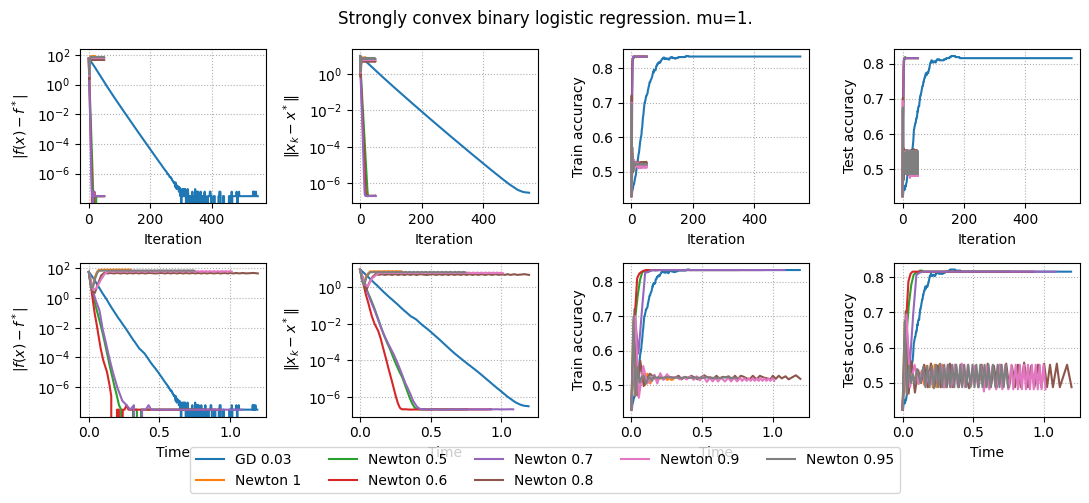

In [6]:
params = {
    "mu": 1,
    "m": 1000,
    "n": 100,
    "methods": [
        {"method": "GD", "learning_rate": 3e-2, "iterations": 550},
        {"method": "Newton", "iterations": 20},
        {"method": "Newton", "learning_rate": 5e-1, "iterations": 50},
        {"method": "Newton", "learning_rate": 6e-1, "iterations": 50},
        {"method": "Newton", "learning_rate": 7e-1, "iterations": 50},
        {"method": "Newton", "learning_rate": 8e-1, "iterations": 50},
        {"method": "Newton", "learning_rate": 9e-1, "iterations": 50},
        {"method": "Newton", "learning_rate": 0.95, "iterations": 50}
    ],
}

results, params = run_experiments(params)
plot_results(results, params)

### 4) Здесь можно увидеть сублинейную сходимость, а также что при больших LR GD cстабилизируется быстрее и достигает большой точности. Также при подборе шага можно использовать условие Армихо

/tmp/ipykernel_4624/884175311.py:34: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.array(y, dtype=jnp.float64)


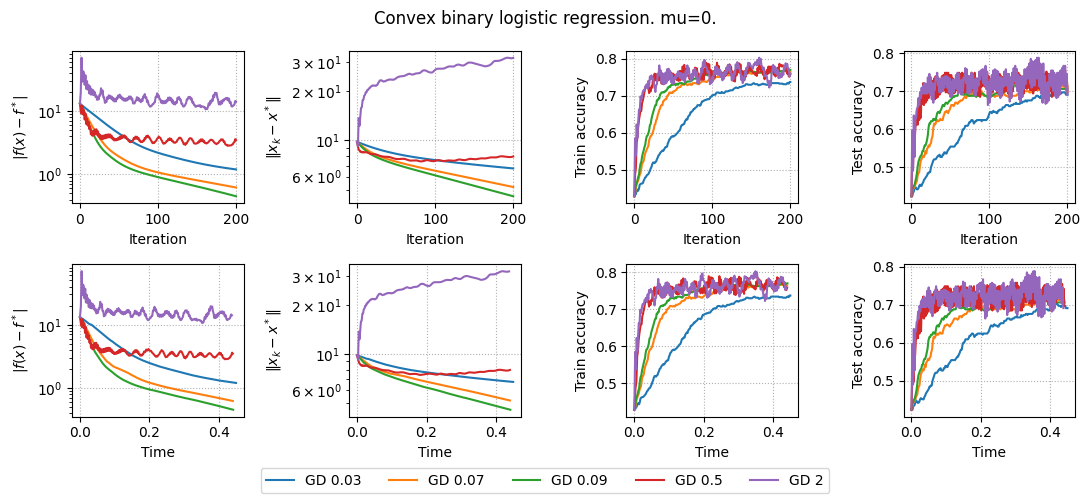

In [7]:
params = {
    "mu": 0,
    "m": 1000,
    "n": 100,
    "methods": [
        {"method": "GD", "learning_rate": 3e-2, "iterations": 200},
        {"method": "GD", "learning_rate": 7e-2, "iterations": 200},
        {"method": "GD", "learning_rate": 9e-2, "iterations": 200},
        {"method": "GD", "learning_rate": 5e-1, "iterations": 200},
        {"method": "GD", "learning_rate": 2, "iterations": 200},
    ],
}

results, params = run_experiments(params)
plot_results(results, params)

### 5) Предполагаю, что дэмпфированный метод Ньютона не сходится из-за слабой обусловленности гессиана

/tmp/ipykernel_4624/884175311.py:34: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.array(y, dtype=jnp.float64)


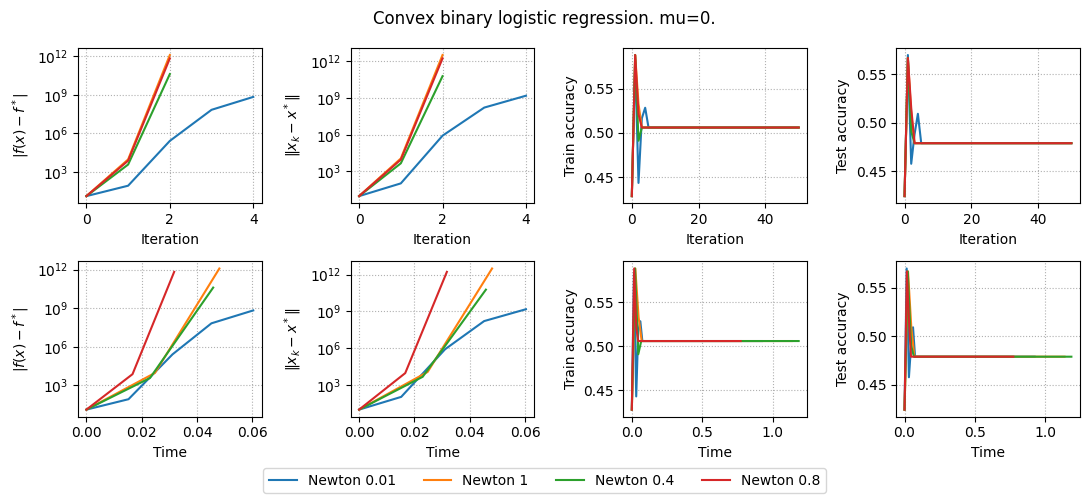

In [8]:
params = {
    "mu": 0,
    "m": 1000,
    "n": 100,
    "methods": [
        {
            "method": "Newton",
            "learning_rate": 1e-2,
            "iterations": 50,
        },
        {
            "method": "Newton",
            "iterations": 50,
        },
        {
            "method": "Newton",
            "learning_rate": 4e-1,
            "iterations": 50,
        },
        {
            "method": "Newton",
            "learning_rate": 8e-1,
            "iterations": 50,
        },
    ]
}

results, params = run_experiments(params)
plot_results(results, params)

### 6) Несмотря не теорию, у меня не вышло получить линейную сходимость этого метода, плюс он является вычислительно более сложным и долгим по сравнению с классическим. Считаю его применение уместным только при среднем числе итеарций при невыгодности метода Ньютона по времени, при этом этот метод требует много памяти

/tmp/ipykernel_4624/3880368507.py:34: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.array(y, dtype=jnp.float64)


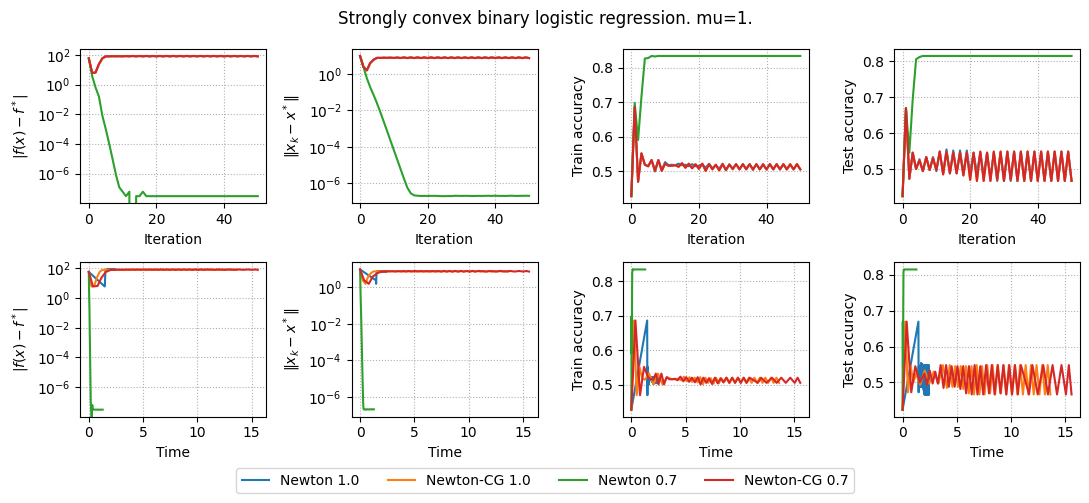

In [25]:
params_compare = {
    "mu": 1,
    "m": 1000,
    "n": 100,
    "methods": [
        {
            "method": "Newton",
            "learning_rate": 1.0,
            "iterations": 50,
        },
        {
            "method": "Newton-CG",
            "learning_rate": 1.0,
            "iterations": 50,
        },
        {
            "method": "Newton",
            "learning_rate": 0.7,
            "iterations": 50,
        },
        {
            "method": "Newton-CG",
            "learning_rate": 0.7,
            "iterations": 50,
        },
    ]
}

results_compare, params_compare = run_experiments(params_compare)
plot_results(results_compare, params_compare)

### 7) Наш финальный метод имеет линейный тип сходимости и позволяет обходиться без вычисления гессиана на большом числе итераций. (>1000). Временная сложность этого алгоритма значительно ниже предыдущих методов O(k*N) и также имеет линейную память, что делает его использование эффективным в таких ситуациях

/tmp/ipykernel_4624/3869325509.py:34: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.array(y, dtype=jnp.float64)


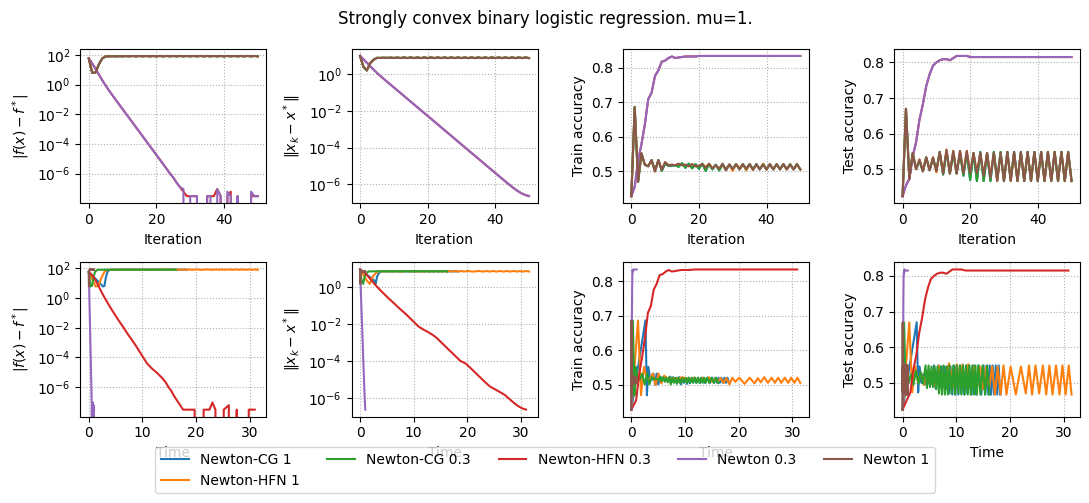

In [28]:
params = {
    "mu": 1,
    "m": 1000,
    "n": 100,
    "methods": [
        {
            "method": "Newton-CG",
            "learning_rate": 1,
            "iterations": 50,
        },
        {
            "method": "Newton-HFN",
            "learning_rate": 1,
            "iterations": 50,
        },
        {
            "method": "Newton-CG",
            "learning_rate": 3e-1,
            "iterations": 50,
        },
        {
            "method": "Newton-HFN",
            "learning_rate": 3e-1,
            "iterations": 50,
        },
        {
            "method": "Newton",
            "learning_rate": 3e-1,
            "iterations": 50,
        },
        {
            "method": "Newton",
            "learning_rate": 1,
            "iterations": 50,
        },
    ]
}

results, params = run_experiments(params)
plot_results(results, params)